First 5 rows:
    radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1809             0.05883  ...     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3

/home/janani/Desktop/Asignment/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6236 - loss: 0.6782 - val_accuracy: 0.6813 - val_loss: 0.6701
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7665 - loss: 0.6463 - val_accuracy: 0.7363 - val_loss: 0.6384
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8516 - loss: 0.6010 - val_accuracy: 0.7802 - val_loss: 0.5931
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8764 - loss: 0.5435 - val_accuracy: 0.8352 - val_loss: 0.5378
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9066 - loss: 0.4724 - val_accuracy: 0.8352 - val_loss: 0.4718
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9011 - loss: 0.3994 - val_accuracy: 0.8571 - val_loss: 0.4122
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9093 - loss: 0.3389 - val_accuracy: 0.8132 - val_loss: 0.3769
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9121 - loss: 0.2988 - val_accuracy: 0.8681 - val_loss: 0.3238
Epo

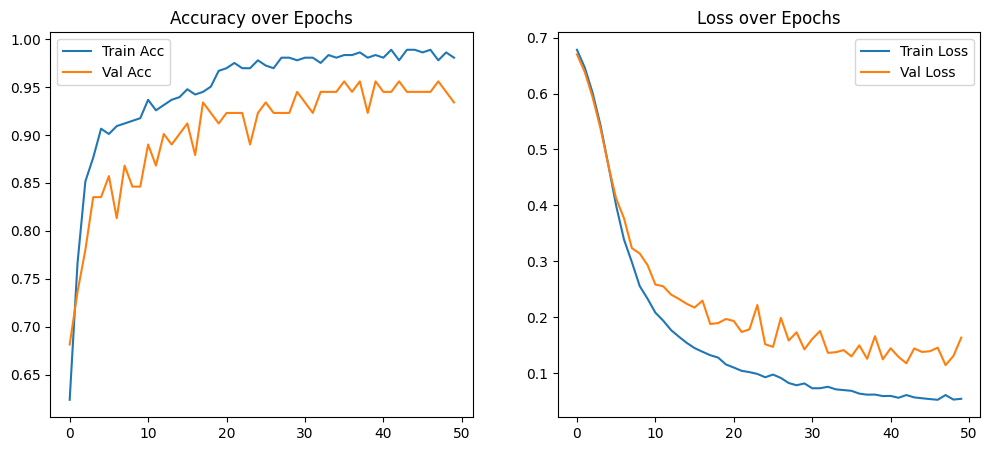

In [ ]:
# Workshop #6 - Cancer Classification (Logistic Regression + Neural Network)
# Fixed version - auto-detects target column and ensures numeric y

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

# 1. Load the file
file_path = 'csv/cancer.csv'  # Change if filename is different (e.g., breast_cancer.csv, data.csv)
df = pd.read_csv(file_path)

# Print diagnostics
print("First 5 rows:\n", df.head())
print("\nAll columns:", df.columns.tolist())
print("\nShape:", df.shape)

# 2. Clean & detect target
# Drop common junk columns
for col in ['id', 'Unnamed: 0']:
    if col in df.columns:
        df = df.drop(col, axis=1)

# Find target column (look for common names or binary-like content)
possible_targets = ['diagnosis', 'target', 'Class', 'class', 'label', 'Diagnosis', 'cancer']
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    # Fallback: first column with only 2 unique values (B/M or 0/1)
    for col in df.columns:
        if df[col].nunique() == 2:
            target_col = col
            break

if target_col is None:
    raise ValueError("Could not find target column. Please check columns and set manually.")

print(f"\nDetected target column: '{target_col}'")
print("Unique target values:", df[target_col].unique())

# Separate X and y
X = df.drop(target_col, axis=1)
y = df[target_col]

# Force encode y to numeric (0/1) if it's string/object
if y.dtype == 'object' or y.dtype == 'category' or y.dtype == 'str':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Target encoded (0/1):", dict(zip(le.classes_, range(len(le.classes_)))))
else:
    print("Target already numeric:", y.value_counts())

# All features must be numeric – scale them
# Drop any remaining non-numeric if needed (rare in this dataset)
X = X.select_dtypes(include=[np.number])  # Keep only numeric columns

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)

# 3. Logistic Regression
print("\n=== Logistic Regression ===")
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print(classification_report(y_test, y_pred_lr, target_names=['Benign (0)', 'Malignant (1)']))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

# 4. Neural Network
print("\n=== Neural Network ===")
model = Sequential([
    Dense(30, input_dim=X_train.shape[1], activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Evaluate NN
y_pred_nn = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
y_prob_nn = model.predict(X_test, verbose=0).flatten()

print("Accuracy:", round(accuracy_score(y_test, y_pred_nn), 4))
print(classification_report(y_test, y_pred_nn, target_names=['Benign (0)', 'Malignant (1)']))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_nn), 4))

# Plot training
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()